In [3]:
import os
print(os.getcwd())

C:\My_Files\Work\Projects\Malware_Detection\strazh\notebooks


In [4]:
# ── Cell 1: imports ──
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support,
    classification_report, roc_curve
)
import matplotlib.pyplot as plt
import json, os

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EMBER_DIR = PROJECT_ROOT / "data" / "ember2018"

print(f"Resolved EMBER_DIR: {EMBER_DIR}")
print(f"Exists: {EMBER_DIR.exists()}")  # wherever Day 20 downloaded/extracted it

Resolved EMBER_DIR: C:\My_Files\Work\Projects\Malware_Detection\strazh\data\ember2018
Exists: True


In [5]:
# ── Cell 2: load vectorized features ──
# EMBER ships train/test features as flat binary .dat files (memmap-friendly,
# because 1.1M rows x 2381 float32 cols is too big to casually load as CSV)

def load_ember_split(data_dir, split, n_features=2381):
    X_path = data_dir / f"X_{split}.dat"
    y_path = data_dir / f"y_{split}.dat"

    y = np.memmap(y_path, dtype=np.float32, mode="r")
    n_rows = y.shape[0]
    X = np.memmap(X_path, dtype=np.float32, mode="r", shape=(n_rows, n_features))
    return np.array(X), np.array(y)  # copy out of memmap into normal arrays

X_train, y_train = load_ember_split(EMBER_DIR, "train")
X_test,  y_test  = load_ember_split(EMBER_DIR, "test")

In [6]:
# ── Cell 3: drop unlabeled rows ──
# EMBER train set includes unlabeled samples marked y == -1 (used for
# semi-supervised experiments in the original paper). We don't want those here.
train_mask = y_train != -1
X_train, y_train = X_train[train_mask], y_train[train_mask]

print(f"Train: {X_train.shape}, positive rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, positive rate: {y_test.mean():.3f}")

Train: (600000, 2381), positive rate: 0.500
Test:  (200000, 2381), positive rate: 0.500


In [7]:
# ── Cell 4: train XGBoost ──
model = xgb.XGBClassifier(
    n_estimators=500,       # how many trees to sequentially add
    max_depth=6,            # how deep each individual tree can grow
    learning_rate=0.05,     # how much each new tree's correction counts
    subsample=0.8,          # each tree sees 80% of rows (reduces overfitting)
    colsample_bytree=0.8,   # each tree sees 80% of columns (same reason)
    eval_metric="auc",
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=25,  # print progress every 25 trees
)

[0]	validation_0-auc:0.89080
[25]	validation_0-auc:0.95247
[50]	validation_0-auc:0.96613
[75]	validation_0-auc:0.97404
[100]	validation_0-auc:0.97796
[125]	validation_0-auc:0.98062
[150]	validation_0-auc:0.98245
[175]	validation_0-auc:0.98374
[200]	validation_0-auc:0.98460
[225]	validation_0-auc:0.98576
[250]	validation_0-auc:0.98675
[275]	validation_0-auc:0.98734
[300]	validation_0-auc:0.98798
[325]	validation_0-auc:0.98841
[350]	validation_0-auc:0.98888
[375]	validation_0-auc:0.98934
[400]	validation_0-auc:0.98971
[425]	validation_0-auc:0.99010
[450]	validation_0-auc:0.99039
[475]	validation_0-auc:0.99063
[499]	validation_0-auc:0.99087


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [10]:
# ── Cell 5: evaluate ──
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of "malicious"
y_pred = (y_pred_proba >= 0.5).astype(int)         # threshold at 0.5 for P/R/F1

auc = roc_auc_score(y_test, y_pred_proba)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary"
)

print(f"AUC-ROC:   {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["benign", "malicious"]))

AUC-ROC:   0.9909
Precision: 0.9464
Recall:    0.9629
F1:        0.9546

              precision    recall  f1-score   support

      benign       0.96      0.95      0.95    100000
   malicious       0.95      0.96      0.95    100000

    accuracy                           0.95    200000
   macro avg       0.95      0.95      0.95    200000
weighted avg       0.95      0.95      0.95    200000



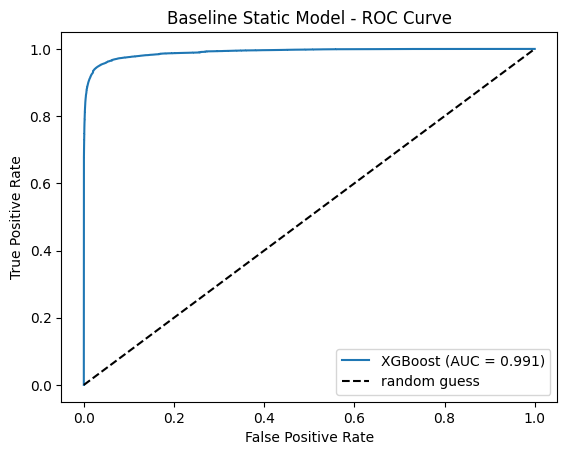

In [13]:
# ── Cell 6: plot ROC curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Static Model - ROC Curve")
plt.legend()
plt.savefig(PROJECT_ROOT / "notebooks" / "baseline_roc_curve.png")
plt.show()

In [14]:
# ── Cell 7: top feature importances (for the checkpoint) ──
importances = model.feature_importances_
top_20_idx = np.argsort(importances)[::-1][:20]
for idx in top_20_idx:
    print(f"feature_{idx}: {importances[idx]:.4f}")

feature_637: 0.0780
feature_503: 0.0349
feature_511: 0.0328
feature_2141: 0.0184
feature_611: 0.0135
feature_2178: 0.0127
feature_2359: 0.0116
feature_2084: 0.0113
feature_639: 0.0110
feature_633: 0.0109
feature_2380: 0.0094
feature_510: 0.0084
feature_502: 0.0082
feature_1793: 0.0079
feature_655: 0.0078
feature_1431: 0.0071
feature_1411: 0.0066
feature_683: 0.0064
feature_1343: 0.0064
feature_665: 0.0059


In [15]:
# ── Cell 8: save the model ──
os.makedirs("models", exist_ok=True)
model.save_model("models/baseline_static.json")
print("Saved to models/baseline_static.json")

Saved to models/baseline_static.json
